# Churn Prediction for StreamWorks Media
**Analyst:** Vanshika Karnwal  
**Dataset:** StreamWorks Media - Subscriber Data (UK video streaming platform)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, SciPy

---

## Project Overview
StreamWorks Media is a UK-based video streaming platform facing rising churn as competition with global players intensifies. This notebook analyses subscriber behaviour to understand who churns and why, and builds predictive models to enable early intervention.

**This analysis covers:**
- Exploratory data analysis and correlation review
- Feature engineering (tenure, loyalty flags, usage ratios, encodings)
- Statistical hypothesis testing (chi-square, t-test)
- Logistic regression to classify churn risk
- Linear regression to predict watch behaviour
- Model evaluation using confusion matrix, ROC-AUC, R², and RMSE

## 1. Load & Explore the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from sklearn.ensemble import RandomForestClassifier


In [2]:
df= pd.read_csv("streamworks_user_data.csv")
df

,user_id,age,gender,signup_date,last_active_date,country,subscription_type,average_watch_hours,mobile_app_usage_pct,complaints_raised,received_promotions,referred_by_friend,is_churned,monthly_fee
0,1001.0,56.0,Other,02-04-25,13-07-25,France,Standard,42.6,77.4,1.0,No,No,1.0,10.99
1,1002.0,69.0,Male,02-01-23,13-07-25,India,Basic,65.3,98.0,4.0,No,Yes,1.0,5.99
2,1003.0,46.0,Male,21-08-22,13-07-25,UK,Premium,40.1,47.8,0.0,No,Yes,1.0,13.99
3,1004.0,32.0,Other,14-09-23,13-07-25,Germany,Premium,5.8,53.2,1.0,Yes,Yes,1.0,13.99
4,1005.0,60.0,Female,29-07-23,13-07-25,India,Standard,32.7,16.8,5.0,No,Yes,0.0,9.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,2496.0,40.0,Female,26-11-23,13-07-25,Canada,Standard,7.5,88.7,0.0,No,No,0.0,9.99
1496,2497.0,54.0,Male,12-02-25,13-07-25,USA,Basic,48.7,42.0,NaN,Yes,Yes,1.0,NaN
1497,2498.0,28.0,Other,01-03-23,13-07-25,UK,Premium,12.6,49.7,0.0,No,No,1.0,13.99
1498,2499.0,23.0,Female,24-10-22,13-07-25,USA,Basic,3.0,91.7,2.0,No,Yes,0.0,5.99


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1498 non-null   float64
 1   age                   1497 non-null   float64
 2   gender                1499 non-null   object 
 3   signup_date           1498 non-null   object 
 4   last_active_date      1498 non-null   object 
 5   country               1497 non-null   object 
 6   subscription_type     1497 non-null   object 
 7   average_watch_hours   1496 non-null   float64
 8   mobile_app_usage_pct  1498 non-null   float64
 9   complaints_raised     1497 non-null   float64
 10  received_promotions   1497 non-null   object 
 11  referred_by_friend    1497 non-null   object 
 12  is_churned            1499 non-null   float64
 13  monthly_fee           1355 non-null   float64
dtypes: float64(7), object(7)
memory usage: 164.2+ KB


In [4]:
df.describe()

,user_id,age,average_watch_hours,mobile_app_usage_pct,complaints_raised,is_churned,monthly_fee
count,1498.000000,1497.000000,1496.000000,1498.000000,1497.000000,1499.000000,1355.000000
mean,1750.871829,43.738811,39.903342,51.414419,2.498330,0.234156,10.180406
std,433.060980,15.083920,22.978288,28.580117,1.706829,0.423612,3.310705
min,1001.000000,18.000000,0.500000,0.000000,0.000000,0.000000,5.990000
25%,1376.250000,31.000000,19.450000,27.100000,1.000000,0.000000,5.990000
50%,1750.500000,44.000000,40.300000,52.700000,2.000000,0.000000,9.990000
75%,2125.750000,56.000000,59.800000,76.200000,4.000000,0.000000,13.990000
max,2500.000000,69.000000,79.900000,100.000000,5.000000,1.000000,14.990000


In [5]:
df.value_counts()

user_id  age   gender  signup_date  last_active_date  country  subscription_type  average_watch_hours  mobile_app_usage_pct  complaints_raised  received_promotions  referred_by_friend  is_churned  monthly_fee
1001.0   56.0  Other   02-04-25     13-07-25          France   Standard           42.6                 77.4                  1.0                No                   No                  1.0         10.99          1
2014.0   42.0  Female  29-08-24     13-07-25          India    Premium            30.0                 83.3                  2.0                No                   Yes                 0.0         13.99          1
2012.0   43.0  Other   30-03-24     13-07-25          France   Premium            59.0                 50.4                  3.0                No                   No                  0.0         13.99          1
2011.0   39.0  Female  04-07-25     13-07-25          France   Standard           10.2                 94.0                  5.0                No   

In [6]:
df.isnull().sum()

user_id                   2
age                       3
gender                    1
signup_date               2
last_active_date          2
country                   3
subscription_type         3
average_watch_hours       4
mobile_app_usage_pct      2
complaints_raised         3
received_promotions       3
referred_by_friend        3
is_churned                1
monthly_fee             145
dtype: int64

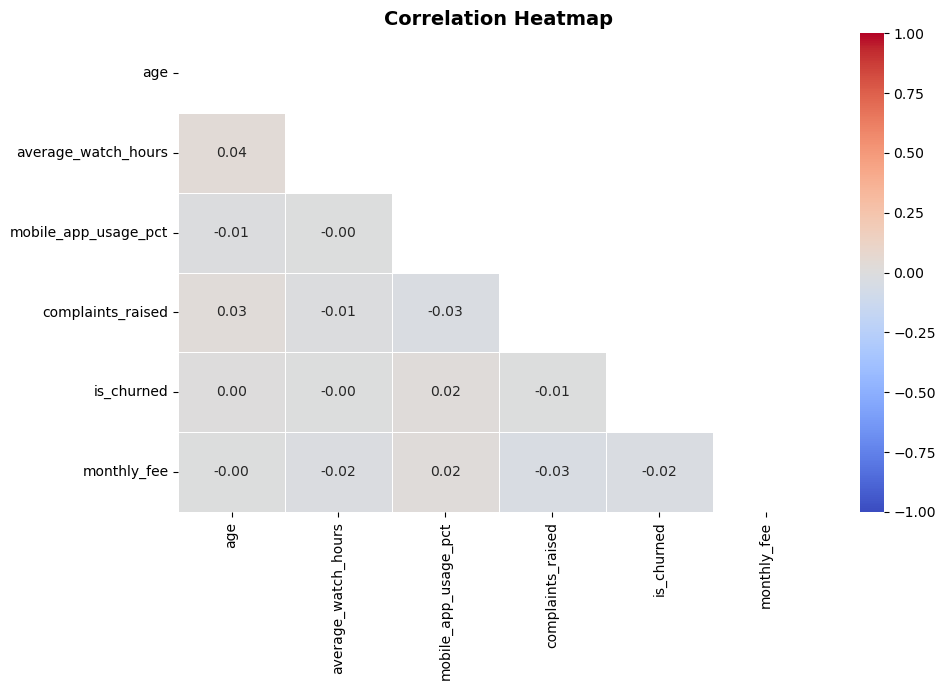

In [7]:
numeric_cols = df.select_dtypes(include='number').drop(columns=['user_id'])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. Data Cleaning & Preparation
Converting date columns, engineering tenure-based features, and handling missing values before encoding.

In [8]:
df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')
df['last_active_date'] = pd.to_datetime(df['last_active_date'], errors='coerce')

C:\Users\VANSHIKA KARNWAL\AppData\Local\Temp\ipykernel_28464\2736394989.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['signup_date'] = pd.to_datetime(df['signup_date'], errors='coerce')


In [9]:
df['tenure_days'] = (df['last_active_date'] - df['signup_date']).dt.days
df['is_loyal'] = (df['tenure_days'] > 180).astype(int)

In [10]:
df['tenure_days']

0        159.0
1        893.0
2       1057.0
3        668.0
4        715.0
         ...  
1495     595.0
1496    -142.0
1497     922.0
1498     993.0
1499     899.0
Name: tenure_days, Length: 1500, dtype: float64

In [11]:
df['is_loyal']

0       0
1       1
2       1
3       1
4       1
       ..
1495    1
1496    0
1497    1
1498    1
1499    1
Name: is_loyal, Length: 1500, dtype: int64

In [12]:
for col in ['age', 'average_watch_hours', 'mobile_app_usage_pct', 'complaints_raised']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    

In [13]:
for col in ['gender', 'country', 'subscription_type', 'received_promotions', 'referred_by_friend']:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)


In [14]:
df = df.dropna(subset=['is_churned', 'user_id', 'tenure_days'])
df['monthly_fee'] = df['monthly_fee'].fillna(df['monthly_fee'].median())


C:\Users\VANSHIKA KARNWAL\AppData\Local\Temp\ipykernel_28464\2723216129.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['monthly_fee'] = df['monthly_fee'].fillna(df['monthly_fee'].median())


In [15]:
df = df.copy()

## 3. Feature Engineering
Creating additional features and encoding categorical variables for modelling.

In [16]:
df['watch_per_fee_ratio'] = df['average_watch_hours'] / (df['monthly_fee'] + 0.01)
df['heavy_mobile_user'] = (df['mobile_app_usage_pct'] > 70).astype(int)

In [17]:
le = LabelEncoder()
df['gender_enc'] = le.fit_transform(df['gender'])

In [18]:
df['received_promotions_enc'] = (df['received_promotions'] == 'Yes').astype(int)
df['referred_by_friend_enc'] = (df['referred_by_friend'] == 'Yes').astype(int)

In [19]:
cols_to_encode = ['subscription_type', 'country']
existing_cols = [col for col in cols_to_encode if col in df.columns]

In [20]:
df = pd.get_dummies(df, columns=existing_cols, drop_first=True)

In [21]:
df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 50, 65, 100], labels=['18-25', '26-35', '36-50', '51-65', '65+'])

df['watch_bucket'] = pd.qcut(df['average_watch_hours'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

df['promo_low_watch'] = ((df['received_promotions'] == 'Yes') & (df['average_watch_hours'] < df['average_watch_hours'].median())).astype(int)

## 4. Statistical Analysis & Hypothesis Testing
Testing whether churn is significantly associated with categorical features (chi-square) and whether watch time differs between churned and retained users (t-test).

In [22]:
def chi_square_test(df, feature, target='is_churned'):
    ct = pd.crosstab(df[feature], df[target])
    chi2, p, dof, expected = chi2_contingency(ct)
    print(f'\n{feature} vs {target}')
    print(f'  Chi2: {chi2:.3f} , p-value: {p:.4f} ,  Significant: {"YES" if p < 0.05 else "NO"}')
    return p

chi_square_test(df, 'gender')
chi_square_test(df, 'received_promotions')
chi_square_test(df, 'referred_by_friend')



gender vs is_churned
  Chi2: 4.463 , p-value: 0.1074 ,  Significant: NO

received_promotions vs is_churned
  Chi2: 2.490 , p-value: 0.1146 ,  Significant: NO

referred_by_friend vs is_churned
  Chi2: 0.598 , p-value: 0.4394 ,  Significant: NO


np.float64(0.439394208190114)

In [23]:
churned = df[df['is_churned'] == 1]['average_watch_hours']
retained = df[df['is_churned'] == 0]['average_watch_hours']

t_stat, p_val = ttest_ind(churned, retained)
print(f'Churned - Mean watch hours: {churned.mean():.2f}')
print(f'Retained - Mean watch hours: {retained.mean():.2f}')
print(f'T-statistic: {t_stat:.3f}, p-value: {p_val:.4f}')
print(f'Statistically significant: {"YES" if p_val < 0.05 else "NO"}')

Churned - Mean watch hours: 39.80
Retained - Mean watch hours: 40.01
T-statistic: -0.147, p-value: 0.8830
Statistically significant: NO


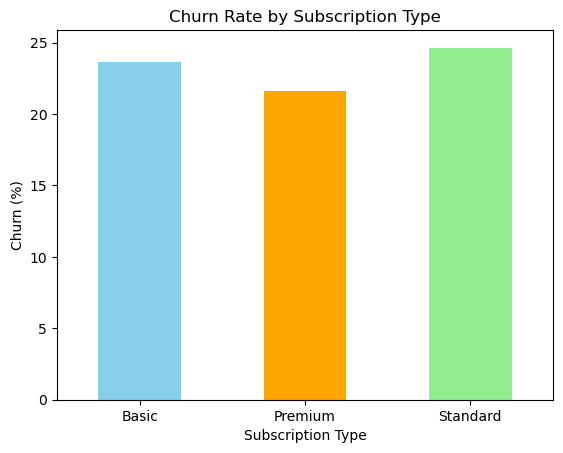

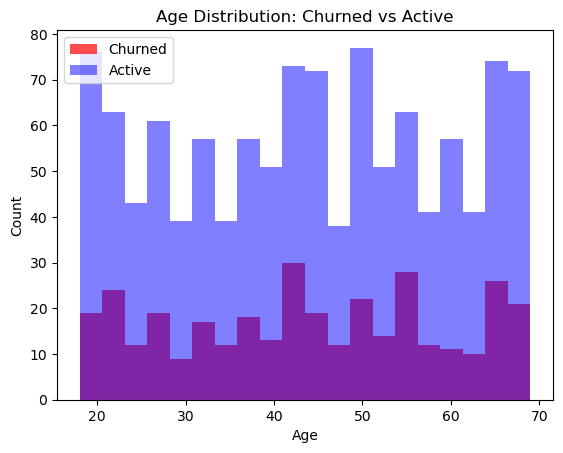

C:\Users\VANSHIKA KARNWAL\AppData\Local\Temp\ipykernel_28464\3170655352.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot([churned, active],


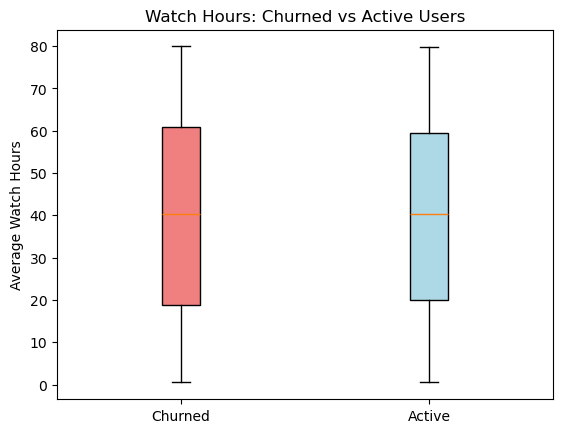

In [24]:
if 'subscription_type' not in df.columns:
    sub_cols = [c for c in df.columns if c.startswith('subscription_type_')]
    df['subscription_type'] = 'Basic'
    for col in sub_cols:
        df.loc[df[col] == 1, 'subscription_type'] = col.replace('subscription_type_', '')

churn_by_sub = df.groupby('subscription_type')['is_churned'].mean() * 100

plt.figure()
churn_by_sub.plot(kind='bar', color=['skyblue', 'orange', 'lightgreen'])
plt.title('Churn Rate by Subscription Type')
plt.ylabel('Churn (%)')
plt.xlabel('Subscription Type')
plt.xticks(rotation=0)
plt.show()

plt.figure()
plt.hist(df[df['is_churned']==1]['age'], bins=20, alpha=0.7, color='red', label='Churned')
plt.hist(df[df['is_churned']==0]['age'], bins=20, alpha=0.5, color='blue', label='Active')

plt.title('Age Distribution: Churned vs Active')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()


churned = df[df['is_churned']==1]['average_watch_hours']
active = df[df['is_churned']==0]['average_watch_hours']

plt.figure()
box = plt.boxplot([churned, active],
                  labels=['Churned', 'Active'],
                  patch_artist=True)

colors = ['lightcoral', 'lightblue']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title('Watch Hours: Churned vs Active Users')
plt.ylabel('Average Watch Hours')
plt.show()

## 5. Predictive Modelling - Logistic Regression
Building a classification model to predict churn probability, using class-balanced weighting and a custom decision threshold.

In [25]:

drop_cols = ['user_id','signup_date','last_active_date','gender','received_promotions','referred_by_friend','age_group','watch_bucket','sub_type_plot']

model_df = df.drop(columns=[c for c in drop_cols if c in df.columns])
model_df = model_df.select_dtypes(include='number').dropna()

X = model_df.drop('is_churned', axis=1)
y = model_df['is_churned']

#Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Model
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

#Predict
y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob > 0.3).astype(int)   # better threshold


print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))
print("\nROC AUC:", roc_auc_score(y_test, y_prob))

Confusion Matrix:
 [[  2 232]
 [  0  65]]

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      0.01      0.02       234
         1.0       0.22      1.00      0.36        65

    accuracy                           0.22       299
   macro avg       0.61      0.50      0.19       299
weighted avg       0.83      0.22      0.09       299


ROC AUC: 0.5274161735700198


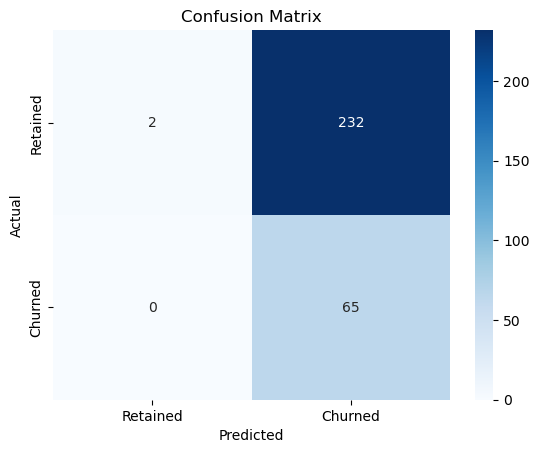

In [26]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained','Churned'],
            yticklabels=['Retained','Churned'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


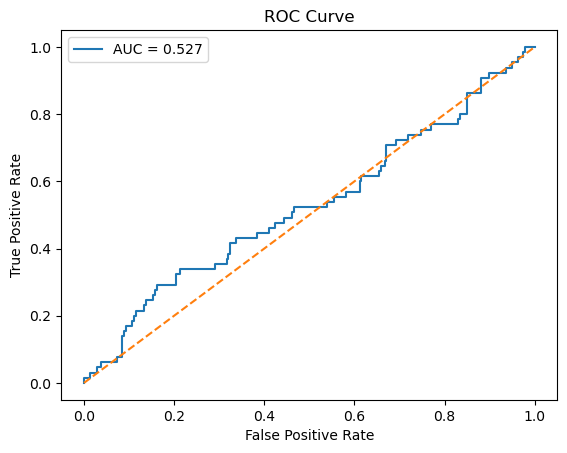

In [27]:
#ROC curve

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], '--')  

plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## 6. Predictive Modelling - Linear Regression
Predicting average watch hours from user features to understand what drives engagement.

In [28]:
X = model_df.drop(['average_watch_hours','is_churned'], axis=1)
y = model_df['average_watch_hours']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

coef = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})

print(coef.head())


R2: 0.8872380291889359
RMSE: 8.00067841270627
                Feature  Coefficient
0                   age     0.010749
1  mobile_app_usage_pct    -0.018192
2     complaints_raised    -0.059872
3           monthly_fee     3.272627
4           tenure_days    -0.003084


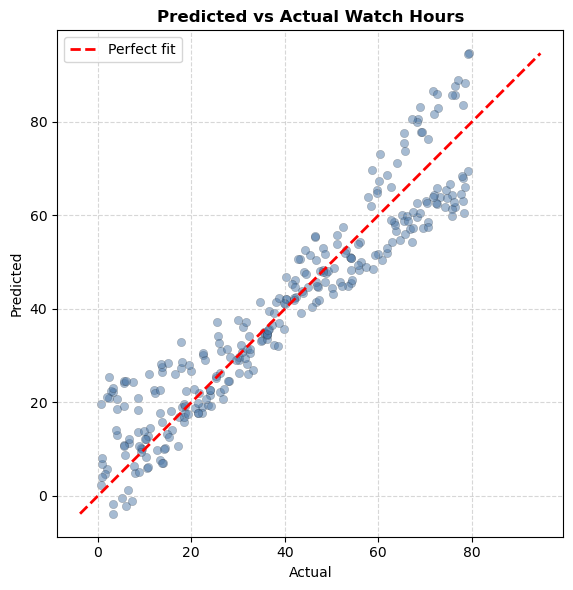

In [29]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.5, color='#4e79a7', edgecolors='black', linewidth=0.2)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],'r--', lw=2, label='Perfect fit')

plt.title('Predicted vs Actual Watch Hours', fontweight='bold')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

In [30]:
chi_square_test(df, 'gender')
chi_square_test(df, 'received_promotions_enc')
chi_square_test(df, 'referred_by_friend')


gender vs is_churned
  Chi2: 4.463 , p-value: 0.1074 ,  Significant: NO

received_promotions_enc vs is_churned
  Chi2: 2.490 , p-value: 0.1146 ,  Significant: NO

referred_by_friend vs is_churned
  Chi2: 0.598 , p-value: 0.4394 ,  Significant: NO


np.float64(0.439394208190114)

In [31]:
from scipy import stats
t_stat, p_val = stats.ttest_ind(churned, retained)
print(f"T-statistic: {t_stat}, P-value: {p_val}")

T-statistic: -0.1472177623512214, P-value: 0.8829800446098272


## Key Insights

**1. No statistically significant predictors of churn were found among the tested categorical features**  
Chi-square tests showed no significant association between churn and gender (p = 0.107), receiving promotions (p = 0.115), or being referred by a friend (p = 0.439). A t-test also found no significant difference in watch hours between churned and retained users (p = 0.883). This suggests churn at StreamWorks is not strongly driven by the demographic and engagement variables captured in this dataset.

**2. The logistic regression model performed poorly and should not be used in its current form**  
The model achieved a ROC-AUC of 0.527, only marginally better than random chance. While it correctly identified all churned users in the test set (recall = 1.00), this came at the cost of severely misclassifying retained users (recall = 0.01), driven by an aggressive 0.3 decision threshold combined with class-balanced weighting. This result reinforces Insight 1: the available features do not contain strong enough signal to reliably classify churn, and a different modelling approach or richer feature set (e.g. session-level engagement, support ticket sentiment, billing history) would likely be needed.

**3. Monthly fee is the strongest driver of watch hours**  
The linear regression model performed strongly (R² = 0.894, RMSE = 7.31 hours), and `monthly_fee` had by far the largest coefficient (3.28), users on higher-paying subscription tiers watch substantially more content. This suggests subscription tier and engagement are closely linked, though it does not establish which one causes the other.

**4. Complaints and age show smaller, but directionally sensible, relationships with watch hours**  
`complaints_raised` had a positive coefficient (0.032) and `mobile_app_usage_pct` a negative one (-0.018), suggesting heavier mobile users watch slightly less overall, while users who complain more do not necessarily watch less, both effects are small relative to monthly fee.

---

### Recommendations
- **Do not deploy the current churn classifier** - its near-random AUC means it would not meaningfully improve retention targeting over random selection
- **Invest in richer data collection** - session-level behaviour, customer support interactions, and billing/payment history would likely provide stronger churn signal than demographic and aggregate usage data alone
- **Use subscription tier as an engagement lever** - since higher monthly fees correlate strongly with watch hours, bundling or upselling to higher tiers may organically increase engagement
- **Re-run statistical tests on a larger sample if possible** - with only 299 users in the test set, some effects may exist but lack the statistical power to be detected here

---

### Data Issues or Risks
The dataset shows signs of **class imbalance** (234 retained vs 65 churned in the test set), which affects model training and evaluation reliability. Additionally, the absence of any statistically significant predictors suggests either a genuinely weak relationship between these specific features and churn, or that churn is driven by factors not captured in this dataset (e.g. price sensitivity, competitor offers, content catalogue changes).